[경고] look-ahead 의심 피처 잔존: ['Account_one_month_max_amount', 'Account_one_month_std_dev', 'Account_dawn_one_month_max_amount', 'Account_dawn_one_month_std_dev', 'Amount_vs_monthly_max_ratio']
       → as-of(시점까지 누적) 재설계 여부 전처리팀 확인 필요

 3차 전처리 통합 분석 — 피처 58개 · valid 홀드아웃 23,860행 · 트리 300
[데이터] train (96140, 58) / valid (23860, 58) | 정상=12(m)

[학습] LightGBM 13-class ...
[검증] 13.3s | Macro-F1=0.6138 | Weighted-F1=0.9942 | Accuracy=0.9949
  ※ Accuracy는 정상 99%라 무의미 → Macro-F1로 판단

 [1] 산출물 4종


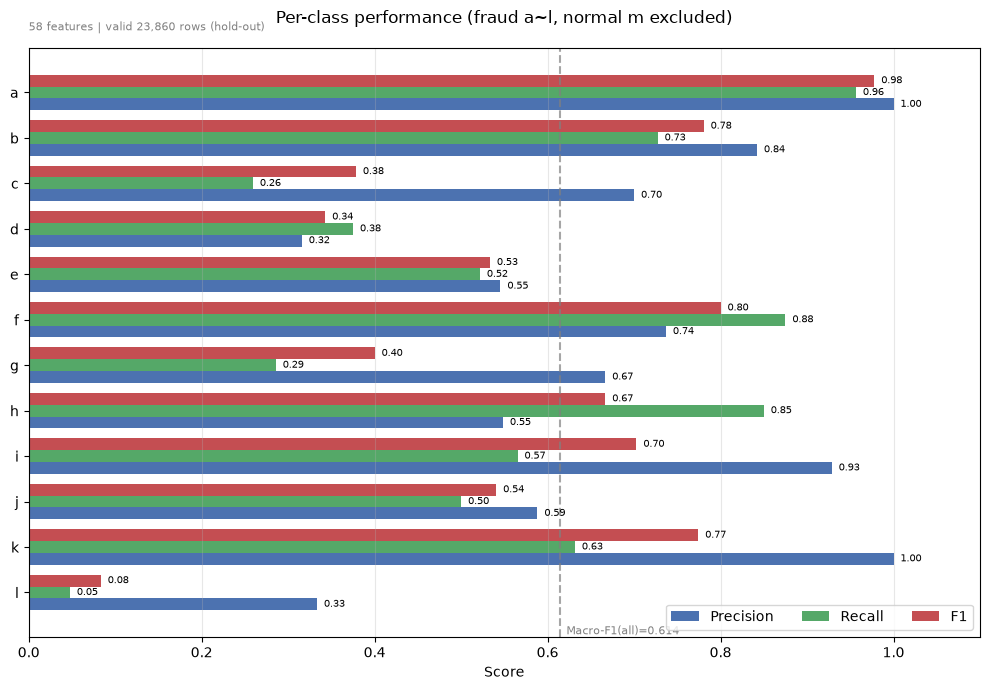


[① 클래스별 성능 표]


,클래스,precision,recall,f1,support
0,a,1.0000,0.9565,0.9778,23
1,b,0.8421,0.7273,0.7805,22
2,c,0.7000,0.2593,0.3784,27
3,d,0.3158,0.3750,0.3429,16
4,e,0.5455,0.5217,0.5333,23
5,f,0.7368,0.8750,0.8000,16
6,g,0.6667,0.2857,0.4000,28
7,h,0.5484,0.8500,0.6667,20
8,i,0.9286,0.5652,0.7027,23
9,j,0.5882,0.5000,0.5405,20


  [약한 유형 Top3] l(0.08), d(0.34), c(0.38)  ← 개선 우선

[SHAP] TreeExplainer 계산 (표본 2000행) ...


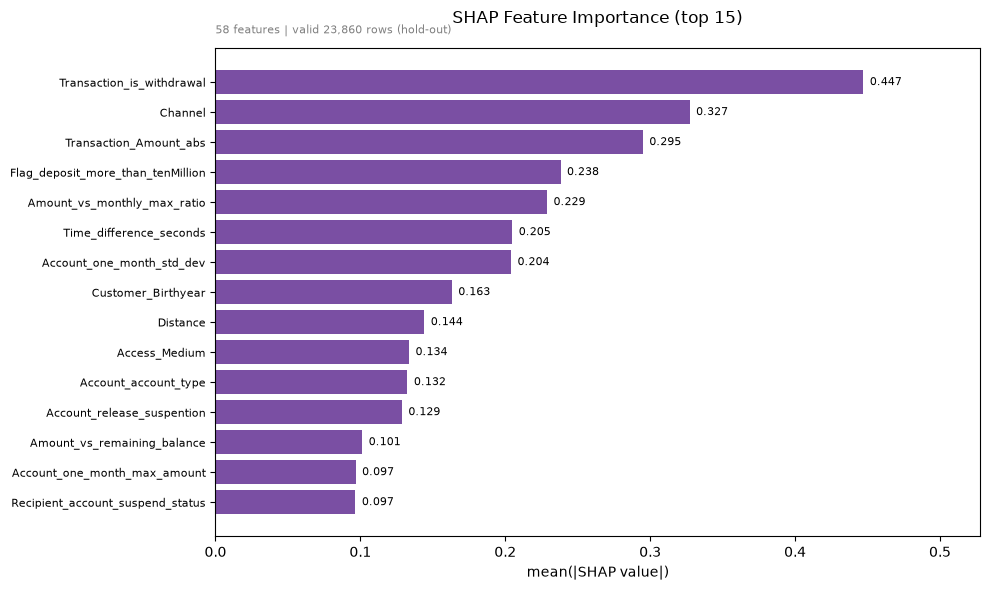


[② SHAP 상위 15 피처 표]


,feature,mean_abs_shap
0,Transaction_is_withdrawal,0.4471
1,Channel,0.3272
2,Transaction_Amount_abs,0.2949
3,Flag_deposit_more_than_tenMillion,0.2381
4,Amount_vs_monthly_max_ratio,0.2288
5,Time_difference_seconds,0.2049
6,Account_one_month_std_dev,0.2040
7,Customer_Birthyear,0.1631
8,Distance,0.1441
9,Access_Medium,0.1336


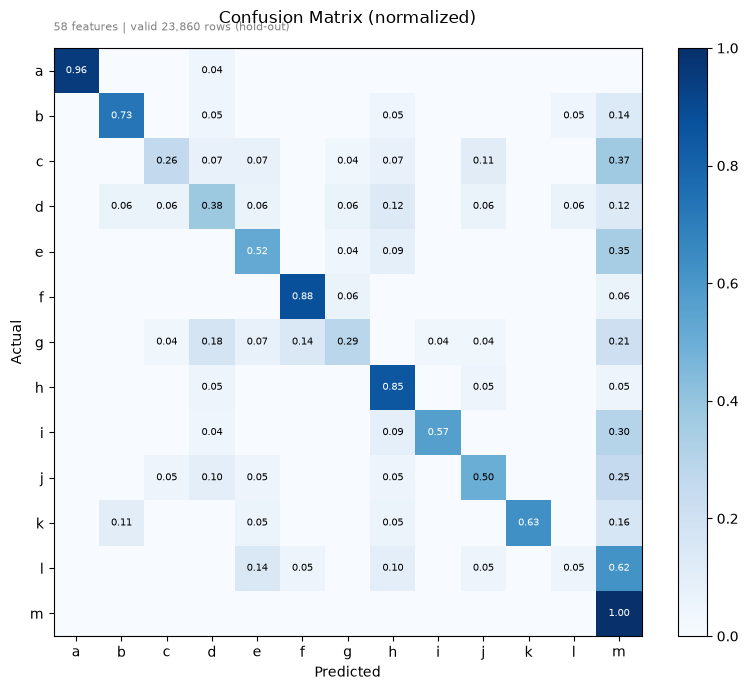


[③ 혼동행렬 표 (건수)]


,pred_a,pred_b,pred_c,pred_d,pred_e,pred_f,pred_g,pred_h,pred_i,pred_j,pred_k,pred_l,pred_m
actual_a,22,0,0,1,0,0,0,0,0,0,0,0,0
actual_b,0,16,0,1,0,0,0,1,0,0,0,1,3
actual_c,0,0,7,2,2,0,1,2,0,3,0,0,10
actual_d,0,1,1,6,1,0,1,2,0,1,0,1,2
actual_e,0,0,0,0,12,0,1,2,0,0,0,0,8
actual_f,0,0,0,0,0,14,1,0,0,0,0,0,1
actual_g,0,0,1,5,2,4,8,0,1,1,0,0,6
actual_h,0,0,0,1,0,0,0,17,0,1,0,0,1
actual_i,0,0,0,1,0,0,0,2,13,0,0,0,7
actual_j,0,0,1,2,1,0,0,1,0,10,0,0,5


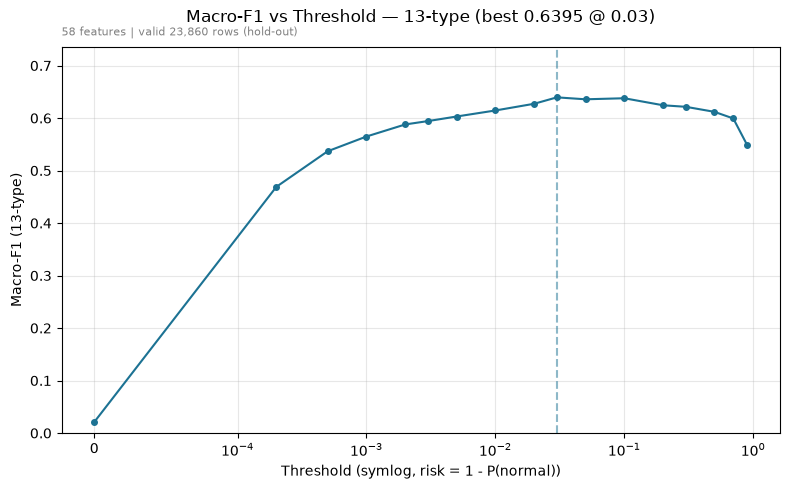


[④ 임계값별 Macro-F1 표 (13유형 분류 기준)]


,임계값,Macro-F1,미탐(FN),오탐(FP)
16,0,0.0210,0,23602
15,0.0002,0.4690,13,389
14,0.0005,0.5368,17,218
13,0.001,0.5649,19,160
12,0.002,0.5879,24,109
11,0.003,0.5943,25,94
10,0.005,0.6030,27,69
9,0.01,0.6145,31,46
8,0.02,0.6273,36,28
7,0.03,0.6395,37,17


  최고점: 임계값 0.03 → Macro-F1 0.6395

 [1-B] 모델 비교 — 한방 vs 2계층 (임계값 조정 포함)
[2계층] stage1(정상 vs 사기) + stage2(사기유형) 학습 ...
  학습 완료 2.7s

[모델별 Macro-F1 비교 (동일 valid 홀드아웃)]


,모델,임계값,Macro-F1,미탐(FN),오탐(FP)
0,한방 13-class (기본 argmax),-,0.6138,59,1
1,한방 + 임계값 조정,0.03,0.6395,37,17
2,2계층 TwoStage (기본 0.5),0.5,0.6105,43,51
3,2계층 + 임계값 조정,0.5,0.6105,43,51


  → 최고: 한방 + 임계값 조정 (임계값 0.03) · Macro-F1 0.6395


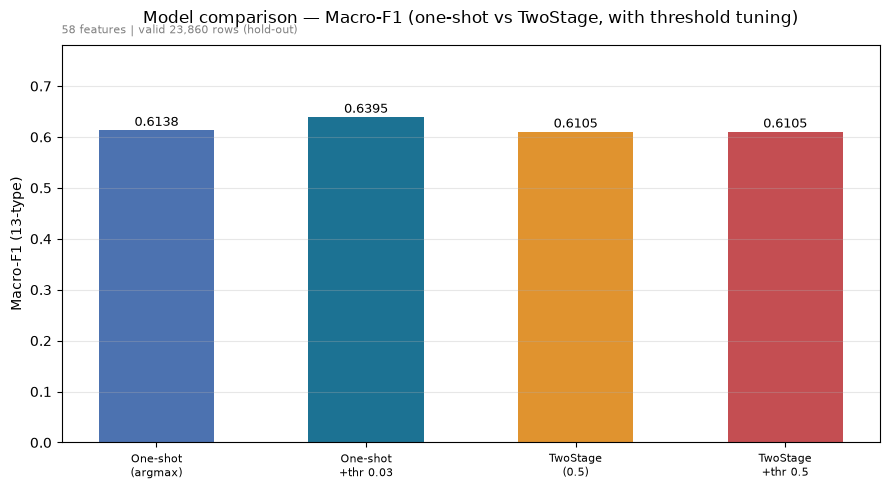


 [2] 비용기반 임계값 조정
  비용 가정: FN(미탐) 1건=17,000,000원 | FP(오탐) A/B/C = 5,000 / 10,000 / 50,000원  ← 팀 합의값으로 교체

[임계값별 Macro-F1 + 기대비용(억) — 범위 0 ~ 0.03]


,임계값,Macro-F1,미탐(FN),오탐(FP),A (FP 5k),B (FP 10k),C (FP 50k)
0,0,0.021,0,23602,1.180,2.360,11.801
1,0.0002,0.469,13,389,2.229,2.249,2.405
2,0.0005,0.537,17,218,2.901,2.912,2.999
3,0.001,0.565,19,160,3.238,3.246,3.310
4,0.002,0.588,24,109,4.085,4.091,4.135
5,0.003,0.594,25,94,4.255,4.259,4.297
6,0.005,0.603,27,69,4.593,4.597,4.625
7,0.008,0.608,30,56,5.103,5.106,5.128
8,0.01,0.614,31,46,5.272,5.275,5.293
9,0.02,0.627,36,28,6.121,6.123,6.134



[최종 채택] Macro-F1 ≥ 0.6 제약 하 기대비용(C (FP 50k)) 최소화
  → 임계값 0.005 | Macro-F1 0.6030 | 미탐 27 오탐 69 | 비용 4.62억
  (성능 최고점: 임계값 0.03 → Macro-F1 0.6395, 비용 6.30억)
  · A (FP 5k) 순수 비용최소: 임계값 0 (비용 1.18억, Macro-F1 0.021)
  · B (FP 10k) 순수 비용최소: 임계값 0.0002 (비용 2.25억, Macro-F1 0.469)
  · C (FP 50k) 순수 비용최소: 임계값 0.0002 (비용 2.40억, Macro-F1 0.469)


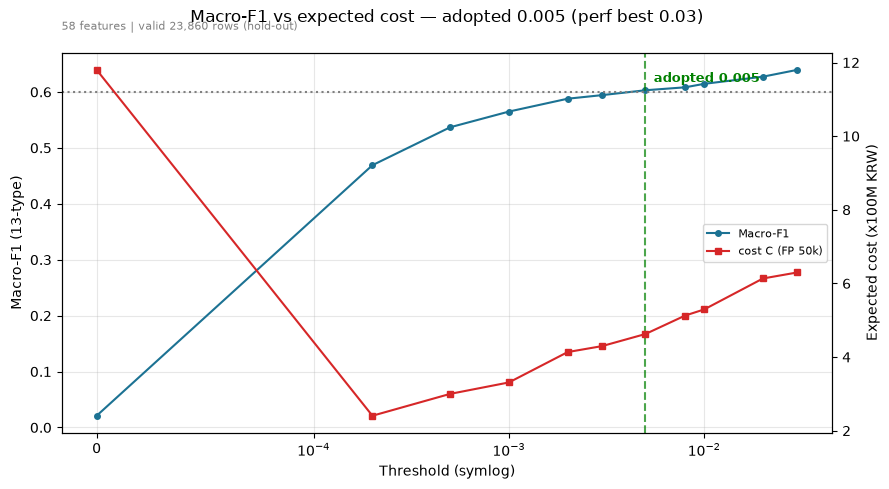


[FN 비용: 실제금액 vs 고정값 가정]


,임계값,미탐(FN),FN실제금액(억),FN고정값(억),차이(%)
0,0,0,0.00,0.00,-
1,0.0002,13,3.15,2.21,42.5
2,0.0005,17,4.25,2.89,47.1
3,0.001,19,4.38,3.23,35.6
4,0.002,24,4.86,4.08,19.1
5,0.003,25,4.86,4.25,14.4
6,0.005,27,5.06,4.59,10.2
7,0.008,30,5.24,5.10,2.7
8,0.01,31,5.32,5.27,0.9
9,0.02,36,6.04,6.12,-1.3


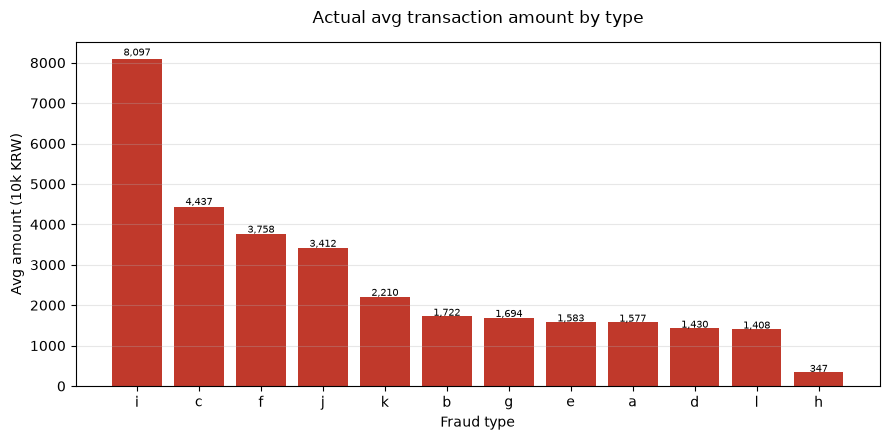


[붕괴 지점 정밀 스캔 (0 ~ 0.0002)]


,임계값,Macro-F1,미탐(FN),오탐(FP)
0,0.000000,0.0210,0,23602
1,0.000010,0.2659,1,1810
2,0.000020,0.3028,3,1348
3,0.000050,0.3633,5,832
4,0.000100,0.4194,7,578
5,0.000150,0.4505,8,459
6,0.000200,0.4690,13,389


  ※ 임계값은 소수 6자리 — 0의 개수 주의(0.000010=십만분의1, 0.000100=만분의1)
  → 붕괴는 '구간'이 아니라 임계값 0 한 점에서만 발생(risk≥0이면 전량 사기 판정)

 [3] 규칙기반 + ML 결합 (하이브리드)
[후보] atom 181개 (검증파생 + 범주형 + 연속형분위수) → 유형별 조합 탐색

[유형별 최고 달성 가능 규칙 (train 기준)]


,유형,최고 precision,hits,조건
0,a,0.933,15,Distance>=301.348 & Time_difference_seconds<=1...
1,b,0.211,19,Amount_vs_remaining_balance>=1.79923 & Custome...
2,c,0.105,38,Amount_vs_remaining_balance>=1.79923 & Custome...
3,d,0.062,162,Transaction_is_withdrawal==1 & Amount_vs_daily...
4,e,0.167,30,Amount_vs_remaining_balance>=1.79923 & large_d...
5,f,0.200,30,Amount_vs_remaining_balance>=1.79923 & Account...
6,g,0.074,27,Account_balance<=2.78403e+06 & Amount_vs_daily...
7,h,0.172,64,Transaction_is_withdrawal==1 & Account_one_mon...
8,i,0.096,239,Transaction_Amount_abs>=5.092e+07 & Transactio...
9,j,0.069,609,Amount_vs_remaining_balance>=1.79923 & Transac...



[precision 기준별 규칙 수 & 성능 변화 (ML 대비)]


...

  [+CTGAN(생성형)] Macro-F1=0.5302 | 사기 평균Recall=0.5112
  [TVAE] 학습 (rows=942, epochs=300) ...


Sampling conditions:  50%|████▉     | 2517/5058 [02:46<02:47, 15.14it/s] 


  [+TVAE(생성형)] Macro-F1=0.5859 | 사기 평균Recall=0.5603
  [SMOTE] 20942 → 26000행 (k_neighbors=5)
  [+SMOTE(규칙기반·참고)] Macro-F1=0.5764 | 사기 평균Recall=0.5502

[증강 방식별 비교 (동일 검증셋 · train만 증강)]


,방식,Macro_F1,사기평균Recall,ΔMacro_F1
0,baseline(증강 전),0.6230,0.5783,0.0000
1,+CTGAN(생성형),0.5302,0.5112,-0.0928
2,+TVAE(생성형),0.5859,0.5603,-0.0371
3,+SMOTE(규칙기반·참고),0.5764,0.5502,-0.0466



[결론] 최고: baseline(증강 전) (Macro-F1 0.623)
  → 어떤 증강도 baseline을 못 넘음: 유형당 표본이 적어(few-shot) 생성모델도 한계.
  → 증강 미채택. 성능 개선은 피처 품질(전처리) 쪽이 우선.
  ※ SMOTE는 규칙기반이라 DACON 최종제출 불가(참고치). CTGAN/TVAE만 제출 후보.


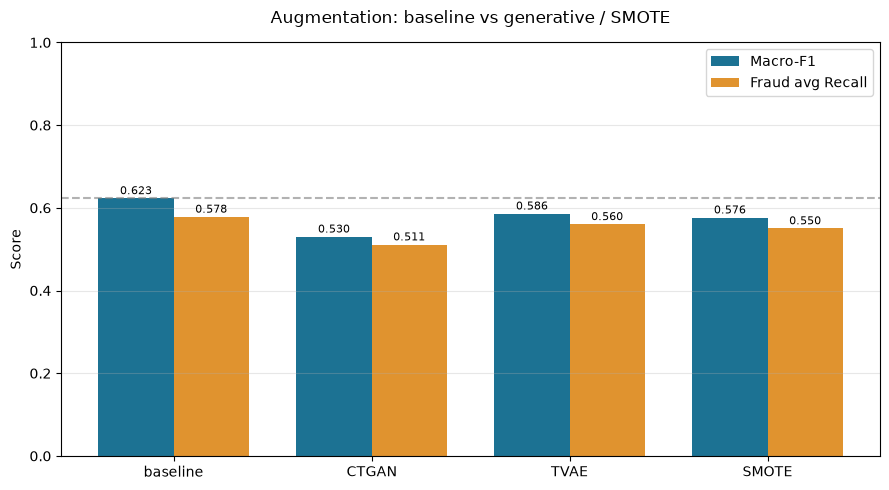


 [5] 최종 요약
  기준        : 피처 58개 · valid 홀드아웃 23,860행 · 트리 300
  최종 모델   : LightGBM 13-class (한방) · Macro-F1 = 0.6138
  모델 비교   : 최고 = 한방 + 임계값 조정 (임계값 0.03) · Macro-F1 0.6395
                · 한방 13-class (기본 argmax)    임계값       - → 0.6138
                · 한방 + 임계값 조정                임계값    0.03 → 0.6395
                · 2계층 TwoStage (기본 0.5)      임계값     0.5 → 0.6105
                · 2계층 + 임계값 조정               임계값     0.5 → 0.6105
  채택 임계값 : 0.005 (Macro-F1 0.6030, 미탐 27, 오탐 69, 비용 4.62억)
  성능 최고점 : 0.03 (Macro-F1 0.6395)
  하이브리드  : 규칙 결합 순이득 없음 → ML 중심 유지
  생성 증강   : 최고 baseline(증강 전) → 증강 이득 제한적
  ⚠️ look-ahead 잔존: 5개 (as-of 재설계 후 재측정 필요)

[완료] 통합 분석 종료.


In [2]:
# [0] 설정 · 데이터 로드 · 모델 학습 (여기부터 순서대로 실행)
import warnings, time, logging
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ===== 설정 =====
DATA_DIR = "/mnt/c/Users/dkstj/Desktop/test_uv/3차 전처리 파일"                 # parquet 폴더
SEED = 42
LGBM_THREADS = 4
N_ESTIMATORS = 300             # 느리면 150~200 (수치가 달라짐)

RUN_PART1 = True               # 산출물 4종
RUN_COMPARE = True             # 모델 비교(한방 기본/임계값 · 2계층 기본/임계값) — 2계층 학습 포함
RUN_PART2 = True               # 비용기반 임계값
RUN_PART3 = True               # 규칙기반 + ML 결합
RUN_PART4 = True               # 생성 AI 합성데이터 증강 비교 (느림: sdv 필요)

LEAK_COLS = ["is_fraud", "fraud_type", "label", "y"]      # 정답 라벨 자동 제거
LOOKAHEAD_SUSPECT = ["Account_one_month_max_amount", "Account_one_month_std_dev",
                     "Account_dawn_one_month_max_amount", "Account_dawn_one_month_std_dev",
                     "Amount_vs_monthly_max_ratio"]        # 남아 있으면 경고만

# 비용 가정 (팀 합의값으로 교체)
FN_COST = 17_000_000
FP_SCENARIOS = {"A (FP 5k)": 5_000, "B (FP 10k)": 10_000, "C (FP 50k)": 50_000}
MACRO_MIN = 0.60               # 최종 채택 조건: Macro-F1 최소기준선
AMOUNT_COL = "Transaction_Amount_abs"

# 임계값 격자
THR_FULL = [0.9, 0.7, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01,
            0.005, 0.003, 0.002, 0.001, 0.0005, 0.0002, 0.0]
THR_BARS = [0.0, 0.0002, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.008, 0.01, 0.02, 0.03]
THR_COLLAPSE = [0.0, 0.00001, 0.00002, 0.00005, 0.0001, 0.00015, 0.0002]

SHAP_SAMPLE = 2000
TOP_FEATURES = 15

# [3] 하이브리드
RULE_MIN_SUPPORT = 15
PRECISION_SCAN = [0.85, 0.70, 0.50, 0.30]
CONT_Q_HI, CONT_Q_LO = [0.90, 0.95, 0.99], [0.01, 0.05, 0.10]
VERIFIED_COMPOSITES = ["large_deposit_and_remote_control", "unused_terminal_and_internet",
                       "limit_check_then_transfer", "suspended_recipient_and_withdrawal",
                       "new_recipient_and_large_amount", "weak_signal_composite_score"]
BOOST_WEIGHT = 0.30

# [4] 증강
TRAIN_SUBSAMPLE_NORMAL = 20000
TARGET_PER_CLASS = 500
GEN_EPOCHS = 300

LGBM_PARAMS = dict(n_estimators=N_ESTIMATORS, learning_rate=0.05, num_leaves=31,
                   subsample=0.9, colsample_bytree=0.9, class_weight="balanced",
                   random_state=SEED, n_jobs=LGBM_THREADS, verbose=-1)
lab = lambda i: chr(ord("a") + int(i))
np.random.seed(SEED)


# ===== 표시 유틸 =====
def _setup_plt():
    import matplotlib
    try:
        ip = get_ipython()  # type: ignore
        if ip is not None:
            ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass
    import matplotlib.pyplot as plt
    logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
    matplotlib.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    return plt


def _table(df, caption=""):
    """VS Code/Jupyter면 표로 렌더링(출력 잘림 방지), 아니면 텍스트."""
    if caption:
        print(f"\n[{caption}]")
    try:
        ip = get_ipython()  # type: ignore
        if ip is not None:
            from IPython.display import display
            display(df); return
    except Exception:
        pass
    print(df.to_string(index=False))


def _head(title):
    print("\n" + "=" * 74); print(f" {title}"); print("=" * 74)


# ===== 데이터 로드 =====
from lightgbm import LGBMClassifier
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)

_d = Path(DATA_DIR)
X_tr = pd.read_parquet(_d / "X_tr.parquet").reset_index(drop=True)
X_va = pd.read_parquet(_d / "X_va.parquet").reset_index(drop=True)
y_tr = pd.read_parquet(_d / "y_tr.parquet").iloc[:, 0].astype(int).reset_index(drop=True)
y_va = pd.read_parquet(_d / "y_va.parquet").iloc[:, 0].astype(int).reset_index(drop=True)

_drop = [c for c in X_tr.columns if c.lower() in [s.lower() for s in LEAK_COLS]]
if _drop:
    print(f"[누수 제거] 정답 라벨 {_drop} 자동 제외")
    X_tr = X_tr.drop(columns=_drop); X_va = X_va.drop(columns=_drop)
_rest = [c for c in LOOKAHEAD_SUSPECT if c in X_tr.columns]
if _rest:
    print(f"[경고] look-ahead 의심 피처 잔존: {_rest}")
    print("       → as-of(시점까지 누적) 재설계 여부 전처리팀 확인 필요")

normal_idx = int(y_tr.value_counts().idxmax())
classes = sorted(y_tr.unique()); labels = [lab(c) for c in classes]
fcols = list(X_tr.columns)
amount = X_va[AMOUNT_COL].values.copy() if AMOUNT_COL in X_va.columns else None
basis = f"{X_tr.shape[1]} features | valid {len(y_va):,} rows (hold-out)"
basis_kr = f"피처 {X_tr.shape[1]}개 · valid 홀드아웃 {len(y_va):,}행 · 트리 {N_ESTIMATORS}"

_head(f"3차 전처리 통합 분석 — {basis_kr}")
print(f"[데이터] train {X_tr.shape} / valid {X_va.shape} | 정상={normal_idx}({lab(normal_idx)})")


# ===== 모델 학습 (1회, 전 파트 공유) =====
print("\n[학습] LightGBM 13-class ...")
_t = time.time()
model = LGBMClassifier(**LGBM_PARAMS).fit(X_tr, y_tr)
pred = model.predict(X_va)
macro = f1_score(y_va, pred, average="macro")
print(f"[검증] {round(time.time()-_t,1)}s | Macro-F1={macro:.4f} | "
      f"Weighted-F1={f1_score(y_va, pred, average='weighted'):.4f} | "
      f"Accuracy={accuracy_score(y_va, pred):.4f}")
print("  ※ Accuracy는 정상 99%라 무의미 → Macro-F1로 판단")

rep = classification_report(y_va, pred, labels=classes, target_names=labels,
                            output_dict=True, zero_division=0)
proba = model.predict_proba(X_va)
_cls = list(model.classes_); _npos = _cls.index(normal_idx)
risk = 1.0 - proba[:, _npos]                       # 위험점수 = 1 − P(정상)
_fp = proba.copy(); _fp[:, _npos] = -1.0
best_fraud = np.asarray(_cls)[_fp.argmax(axis=1)]  # 정상 제외 최고확률 유형
y_arr = np.asarray(y_va); yb = (y_arr != normal_idx)


def thr_predict(thr):
    """위험점수 ≥ thr → 사기(최고확률 유형), 아니면 정상."""
    p = np.full(len(y_arr), normal_idx); m = risk >= thr
    p[m] = best_fraud[m]; return p, m


def thr_scan(grid):
    rows = []
    for t in grid:
        p, m = thr_predict(t)
        fn = int((yb & ~m).sum()); fp = int((~yb & m).sum())
        r = dict(thr=t, macro=round(f1_score(y_arr, p, average="macro"), 4), FN=fn, FP=fp)
        for k, v in FP_SCENARIOS.items():
            r[k] = round((fn * FN_COST + fp * v) / 1e8, 3)
        if amount is not None:
            r["FN실제금액(억)"] = round(float(amount[yb & ~m].sum()) / 1e8, 2)
            r["FN고정값(억)"] = round(fn * FN_COST / 1e8, 2)
        rows.append(r)
    return pd.DataFrame(rows)



#  [1] 산출물 4종 — 클래스별 성능 · SHAP · 혼동행렬 · 임계값별 Macro-F1
if RUN_PART1:
    _head("[1] 산출물 4종")
    plt = _setup_plt()

    # ① 클래스별 성능
    fl = [l for l in labels if l != lab(normal_idx)]
    P = [rep[l]["precision"] for l in fl]; R = [rep[l]["recall"] for l in fl]
    F = [rep[l]["f1-score"] for l in fl]
    yy = np.arange(len(fl)); h = 0.26
    fig, ax = plt.subplots(figsize=(10, 7))
    gs = [ax.barh(yy + h, P, h, label="Precision", color="#4C72B0"),
          ax.barh(yy,     R, h, label="Recall",    color="#55A868"),
          ax.barh(yy - h, F, h, label="F1",        color="#C44E52")]
    ax.set_yticks(yy); ax.set_yticklabels(fl); ax.invert_yaxis()
    ax.set_xlim(0, 1.10); ax.set_xlabel("Score")
    ax.set_title("Per-class performance (fraud a~l, normal m excluded)", pad=18)
    _m = rep["macro avg"]["f1-score"]; ax.axvline(_m, ls="--", color="gray", alpha=.7)
    ax.text(_m + 0.008, ax.get_ylim()[0], f"Macro-F1(all)={_m:.3f}", color="gray", fontsize=8, va="bottom")
    for g in gs:
        for r in g:
            w = r.get_width()
            ax.text(w + 0.008, r.get_y() + r.get_height()/2, f"{w:.2f}", va="center", fontsize=7)
    ax.legend(loc="lower right", ncol=3); ax.grid(axis="x", alpha=.3)
    ax.text(0, 1.03, basis, transform=ax.transAxes, fontsize=8, color="gray")
    fig.tight_layout(); plt.show()

    rows = [{"클래스": l, "precision": round(rep[l]["precision"], 4),
             "recall": round(rep[l]["recall"], 4), "f1": round(rep[l]["f1-score"], 4),
             "support": int(rep[l]["support"])} for l in labels]
    for k in ["macro avg", "weighted avg"]:
        rows.append({"클래스": k, "precision": round(rep[k]["precision"], 4),
                     "recall": round(rep[k]["recall"], 4), "f1": round(rep[k]["f1-score"], 4),
                     "support": int(rep[k]["support"])})
    _table(pd.DataFrame(rows), "① 클래스별 성능 표")
    _weak = sorted({l: rep[l]["f1-score"] for l in fl}.items(), key=lambda x: x[1])[:3]
    print("  [약한 유형 Top3] " + ", ".join(f"{k}({v:.2f})" for k, v in _weak) + "  ← 개선 우선")

    # ② SHAP
    try:
        import shap
        n = min(SHAP_SAMPLE, len(X_va)); Xs = X_va.sample(n, random_state=SEED)
        print(f"\n[SHAP] TreeExplainer 계산 (표본 {n}행) ...")
        sv = shap.TreeExplainer(model).shap_values(Xs)
        if isinstance(sv, list):
            ma = np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
        else:
            a = np.abs(np.asarray(sv)); ma = a.mean(axis=(0, 2)) if a.ndim == 3 else a.mean(axis=0)
        order = np.argsort(ma)[::-1][:TOP_FEATURES]
        names = [fcols[i] for i in order][::-1]; vals = ma[order][::-1]
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(range(len(names)), vals, color="#7A4FA3")
        ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
        ax.set_xlabel("mean(|SHAP value|)"); ax.set_xlim(0, max(vals) * 1.18)
        ax.set_title(f"SHAP Feature Importance (top {TOP_FEATURES})", pad=18)
        ax.text(0, 1.03, basis, transform=ax.transAxes, fontsize=8, color="gray")
        for i, v in enumerate(vals):
            ax.text(v + max(vals)*0.01, i, f"{v:.3f}", va="center", fontsize=8)
        fig.tight_layout(); plt.show()
        _table(pd.DataFrame({"feature": [fcols[i] for i in order],
                             "mean_abs_shap": [round(float(ma[i]), 4) for i in order]}),
               f"② SHAP 상위 {TOP_FEATURES} 피처 표")
    except Exception as e:
        print(f"[SHAP 건너뜀] {e}  (pip install shap)")


    # ③ 혼동행렬
    cm = confusion_matrix(y_va, pred, labels=classes, normalize="true")
    cnt = confusion_matrix(y_va, pred, labels=classes)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix (normalized)", pad=18)
    ax.text(0, 1.03, basis, transform=ax.transAxes, fontsize=8, color="gray")
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = cm[i, j]
            if v >= 0.005:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="white" if v > 0.5 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046); fig.tight_layout(); plt.show()
    _table(pd.DataFrame(cnt, index=[f"actual_{l}" for l in labels],
                        columns=[f"pred_{l}" for l in labels]), "③ 혼동행렬 표 (건수)")


    # ④ 임계값별 Macro-F1 (13유형 기준)
    sc = thr_scan(THR_FULL).sort_values("thr")
    best = sc.loc[sc["macro"].idxmax()]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sc["thr"], sc["macro"], "-o", ms=4, color="#1C7293")
    ax.set_xscale("symlog", linthresh=1e-4)
    ax.axvline(best["thr"], ls="--", color="#1C7293", alpha=.5)
    ax.set_xlabel("Threshold (symlog, risk = 1 - P(normal))"); ax.set_ylabel("Macro-F1 (13-type)")
    ax.set_ylim(0, max(sc["macro"]) * 1.15); ax.grid(alpha=.3)
    ax.set_title(f"Macro-F1 vs Threshold — 13-type (best {best['macro']:.4f} @ {best['thr']:g})", pad=18)
    ax.text(0, 1.03, basis, transform=ax.transAxes, fontsize=8, color="gray")
    fig.tight_layout(); plt.show()
    t = sc[["thr", "macro", "FN", "FP"]].copy()
    t["thr"] = t["thr"].map(lambda v: f"{v:g}")
    t = t.rename(columns={"thr": "임계값", "macro": "Macro-F1", "FN": "미탐(FN)", "FP": "오탐(FP)"})
    _table(t, "④ 임계값별 Macro-F1 표 (13유형 분류 기준)")
    print(f"  최고점: 임계값 {best['thr']:g} → Macro-F1 {best['macro']:.4f}")



#  [1-B] 모델 비교 — 한방(기본/임계값조정) vs 2계층(기본/임계값조정)
cmp_tbl = None
if RUN_COMPARE:
    _head("[1-B] 모델 비교 — 한방 vs 2계층 (임계값 조정 포함)")
    plt = _setup_plt()
    rows = []

    # ① 한방 기본(argmax)
    rows.append({"모델": "한방 13-class (기본 argmax)", "임계값": "-", "Macro-F1": round(macro, 4),
                 "미탐(FN)": int((yb & (pred == normal_idx)).sum()),
                 "오탐(FP)": int(((~yb) & (pred != normal_idx)).sum())})

    # ② 한방 + 임계값 조정 (최고점 자동 탐색)
    _sc1 = thr_scan(THR_FULL); _b1 = _sc1.loc[_sc1["macro"].idxmax()]
    rows.append({"모델": "한방 + 임계값 조정", "임계값": f"{_b1['thr']:g}", "Macro-F1": _b1["macro"],
                 "미탐(FN)": int(_b1["FN"]), "오탐(FP)": int(_b1["FP"])})

    # ③④ 2계층(TwoStage) 학습 → 기본(0.5) / 임계값 조정
    print("[2계층] stage1(정상 vs 사기) + stage2(사기유형) 학습 ...")
    _t2 = time.time()
    _ytr = np.asarray(y_tr)
    s1 = LGBMClassifier(**LGBM_PARAMS).fit(X_tr, (_ytr != normal_idx).astype(int))
    _frm = _ytr != normal_idx
    s2 = LGBMClassifier(**LGBM_PARAMS).fit(X_tr[_frm], _ytr[_frm])
    risk2 = s1.predict_proba(X_va)[:, 1]
    print(f"  학습 완료 {round(time.time()-_t2,1)}s")

    def two_pred(t):
        p = np.full(len(y_arr), normal_idx); m = risk2 >= t
        if m.any():
            p[m] = s2.predict(X_va[m])
        return p, m

    p2, m2 = two_pred(0.5)
    rows.append({"모델": "2계층 TwoStage (기본 0.5)", "임계값": "0.5",
                 "Macro-F1": round(f1_score(y_arr, p2, average="macro"), 4),
                 "미탐(FN)": int((yb & ~m2).sum()), "오탐(FP)": int(((~yb) & m2).sum())})

    _best2 = (0.0, None, 0, 0)
    for t in THR_FULL:
        p_, m_ = two_pred(t)
        mac2 = f1_score(y_arr, p_, average="macro")
        if mac2 > _best2[0]:
            _best2 = (mac2, t, int((yb & ~m_).sum()), int(((~yb) & m_).sum()))
    rows.append({"모델": "2계층 + 임계값 조정", "임계값": f"{_best2[1]:g}",
                 "Macro-F1": round(_best2[0], 4),
                 "미탐(FN)": _best2[2], "오탐(FP)": _best2[3]})

    cmp_tbl = pd.DataFrame(rows)
    _table(cmp_tbl, "모델별 Macro-F1 비교 (동일 valid 홀드아웃)")
    _bp = cmp_tbl.loc[cmp_tbl["Macro-F1"].idxmax()]
    print(f"  → 최고: {_bp['모델']} (임계값 {_bp['임계값']}) · Macro-F1 {_bp['Macro-F1']}")

    fig, ax = plt.subplots(figsize=(9, 5))
    b = ax.bar(range(len(cmp_tbl)), cmp_tbl["Macro-F1"], 0.55,
               color=["#4C72B0", "#1C7293", "#E0932F", "#C44E52"])
    for r, v in zip(b, cmp_tbl["Macro-F1"]):
        ax.text(r.get_x() + r.get_width()/2, r.get_height() + 0.008, f"{v:.4f}",
                ha="center", fontsize=9)
    ax.set_xticks(range(len(cmp_tbl)))
    ax.set_xticklabels(["One-shot\n(argmax)", f"One-shot\n+thr {_b1['thr']:g}",
                        "TwoStage\n(0.5)", f"TwoStage\n+thr {_best2[1]:g}"], fontsize=8)
    ax.set_ylim(0, max(cmp_tbl["Macro-F1"]) * 1.22); ax.set_ylabel("Macro-F1 (13-type)")
    ax.set_title("Model comparison — Macro-F1 (one-shot vs TwoStage, with threshold tuning)", pad=16)
    ax.text(0, 1.03, basis, transform=ax.transAxes, fontsize=8, color="gray")
    ax.grid(axis="y", alpha=.3); fig.tight_layout(); plt.show()


#  [2] 비용기반 임계값 — A/B/C 시나리오 · FN 실제금액 · 붕괴 스캔 · 최종 채택
if RUN_PART2:
    _head("[2] 비용기반 임계값 조정")
    plt = _setup_plt()
    print(f"  비용 가정: FN(미탐) 1건={FN_COST:,}원 | FP(오탐) A/B/C = "
          + " / ".join(f"{v:,}" for v in FP_SCENARIOS.values()) + "원  ← 팀 합의값으로 교체")

    s = thr_scan(THR_BARS).sort_values("thr")
    disp = s[["thr", "macro", "FN", "FP"] + list(FP_SCENARIOS)].copy()
    num = ["macro"] + list(FP_SCENARIOS)
    disp[num] = disp[num].round(3)
    disp["thr"] = disp["thr"].map(lambda v: f"{v:g}")
    disp = disp.rename(columns={"thr": "임계값", "macro": "Macro-F1",
                                "FN": "미탐(FN)", "FP": "오탐(FP)"})
    _table(disp, f"임계값별 Macro-F1 + 기대비용(억) — 범위 0 ~ {max(THR_BARS):g}")

    cname = list(FP_SCENARIOS)[-1]
    best_perf = s.loc[s["macro"].idxmax()]
    ok = s[s["macro"] >= MACRO_MIN]
    pick = ok.loc[ok[cname].idxmin()] if len(ok) else best_perf
    print(f"\n[최종 채택] Macro-F1 ≥ {MACRO_MIN} 제약 하 기대비용({cname}) 최소화")
    print(f"  → 임계값 {pick['thr']:g} | Macro-F1 {pick['macro']:.4f} | "
          f"미탐 {int(pick['FN'])} 오탐 {int(pick['FP'])} | 비용 {pick[cname]:.2f}억")
    print(f"  (성능 최고점: 임계값 {best_perf['thr']:g} → Macro-F1 {best_perf['macro']:.4f}, "
          f"비용 {best_perf[cname]:.2f}억)")
    for n_ in FP_SCENARIOS:
        b = s.loc[s[n_].idxmin()]
        print(f"  · {n_} 순수 비용최소: 임계값 {b['thr']:g} (비용 {b[n_]:.2f}억, Macro-F1 {b['macro']:.3f})")

    # 비용 vs 성능 그래프
    fig, ax1 = plt.subplots(figsize=(9, 5))
    l1, = ax1.plot(s["thr"], s["macro"], "-o", ms=4, color="#1C7293", label="Macro-F1")
    ax1.set_xscale("symlog", linthresh=1e-4)
    ax1.set_xlabel("Threshold (symlog)"); ax1.set_ylabel("Macro-F1 (13-type)")
    ax1.axhline(MACRO_MIN, ls=":", color="gray")
    ax2 = ax1.twinx()
    l2, = ax2.plot(s["thr"], s[cname], "-s", ms=4, color="tab:red", label=f"cost {cname}")
    ax2.set_ylabel("Expected cost (x100M KRW)")
    ax1.axvline(pick["thr"], ls="--", color="green", alpha=.7)
    ax1.annotate(f"adopted {pick['thr']:g}", xy=(pick["thr"], 1.0), xycoords=("data", "axes fraction"),
                 xytext=(6, -14), textcoords="offset points", color="green",
                 fontsize=9, weight="bold", va="top")
    ax1.legend(handles=[l1, l2], loc="center right", fontsize=8)
    ax1.set_title(f"Macro-F1 vs expected cost — adopted {pick['thr']:g} "
                  f"(perf best {best_perf['thr']:g})", pad=22)
    ax1.text(0, 1.06, basis, transform=ax1.transAxes, fontsize=8, color="gray")
    ax1.grid(alpha=.3); fig.tight_layout(); plt.show()

    # FN 실제금액 vs 고정값
    if amount is not None:
        fa = s[["thr", "FN", "FN실제금액(억)", "FN고정값(억)"]].copy()
        fa["차이(%)"] = (((fa["FN실제금액(억)"] - fa["FN고정값(억)"]) /
                         fa["FN고정값(억)"].replace(0, np.nan) * 100)
                        .round(1).fillna("-"))      # FN=0이면 비교 불가 → '-'
        fa["thr"] = fa["thr"].map(lambda v: f"{v:g}")
        _table(fa.rename(columns={"thr": "임계값", "FN": "미탐(FN)"}),
               "FN 비용: 실제금액 vs 고정값 가정")
        types = [c for c in classes if c != normal_idx]
        avg = sorted([(lab(c), amount[y_arr == c].mean() / 1e4) for c in types], key=lambda t: -t[1])
        fig, ax = plt.subplots(figsize=(9, 4.5))
        b = ax.bar([a for a, _ in avg], [v for _, v in avg], color="#c0392b")
        for r, (_, v) in zip(b, avg):
            ax.text(r.get_x() + r.get_width()/2, r.get_height() * 1.01, f"{v:,.0f}",
                    ha="center", fontsize=7)
        ax.set_xlabel("Fraud type"); ax.set_ylabel("Avg amount (10k KRW)")
        ax.set_title("Actual avg transaction amount by type", pad=14)
        ax.grid(axis="y", alpha=.3); fig.tight_layout(); plt.show()

    # 붕괴 정밀 스캔
    col = thr_scan(THR_COLLAPSE).sort_values("thr")[["thr", "macro", "FN", "FP"]]
    col["thr"] = col["thr"].map(lambda v: f"{v:.6f}")
    _table(col.rename(columns={"thr": "임계값", "macro": "Macro-F1",
                               "FN": "미탐(FN)", "FP": "오탐(FP)"}),
           "붕괴 지점 정밀 스캔 (0 ~ 0.0002)")
    print("  ※ 임계값은 소수 6자리 — 0의 개수 주의(0.000010=십만분의1, 0.000100=만분의1)")
    print("  → 붕괴는 '구간'이 아니라 임계값 0 한 점에서만 발생(risk≥0이면 전량 사기 판정)")


#  [3] 규칙기반 + ML 결합 (하이브리드)
if RUN_PART3:
    _head("[3] 규칙기반 + ML 결합 (하이브리드)")
    plt = _setup_plt()

    def _atom_mask(X, a):
        f, op, v = a; col = X[f].values
        return col == v if op == "==" else (col >= v if op == ">=" else col <= v)

    def _cond_mask(X, atoms):
        m = np.ones(len(X), dtype=bool)
        for a in atoms:
            m &= _atom_mask(X, a)
        return m

    def _desc(atoms):
        return " & ".join(f"{a[0]}{a[1]}{a[2]:g}" for a in atoms)

    # 후보 atom: 검증 파생변수 + 범주형 단일 + 연속형 분위수
    atoms = [(c, "==", 1) for c in VERIFIED_COMPOSITES if c in X_tr.columns]
    for c in fcols:
        sc_ = X_tr[c]
        if sc_.nunique() <= 10:
            for v in sorted(sc_.unique()):
                m = (sc_ == v).values
                if 30 <= m.sum() <= len(X_tr) * 0.5:
                    atoms.append((c, "==", int(v) if float(v).is_integer() else float(v)))
        else:
            for q in CONT_Q_HI:
                atoms.append((c, ">=", float(sc_.quantile(q))))
            for q in CONT_Q_LO:
                atoms.append((c, "<=", float(sc_.quantile(q))))
    print(f"[후보] atom {len(atoms)}개 (검증파생 + 범주형 + 연속형분위수) → 유형별 조합 탐색")

    ytr_arr = np.asarray(y_tr)
    cands, per_best = [], {}
    for t in [c for c in classes if c != normal_idx]:
        yt = (ytr_arr == t); tot = int(yt.sum())
        scored = []
        for a in atoms:
            m = _atom_mask(X_tr, a); hit = int((yt & m).sum())
            if hit >= max(tot * 0.2, 5):
                scored.append((hit / m.sum(), a, m))
        scored.sort(key=lambda x: -x[0]); top = scored[:15]
        best_r = (0.0, None, 0)
        for i in range(len(top)):
            for j in range(i + 1, len(top)):
                m2 = top[i][2] & top[j][2]
                if m2.sum() >= RULE_MIN_SUPPORT:
                    p2 = float((yt & m2).sum() / m2.sum())
                    cands.append(([top[i][1], top[j][1]], t, p2, int(m2.sum())))
                    if p2 > best_r[0]: best_r = (p2, [top[i][1], top[j][1]], int(m2.sum()))
                    for l in range(j + 1, len(top)):
                        m3 = m2 & top[l][2]
                        if m3.sum() >= RULE_MIN_SUPPORT:
                            p3 = float((yt & m3).sum() / m3.sum())
                            cands.append(([top[i][1], top[j][1], top[l][1]], t, p3, int(m3.sum())))
                            if p3 > best_r[0]:
                                best_r = (p3, [top[i][1], top[j][1], top[l][1]], int(m3.sum()))
        per_best[lab(t)] = best_r

    _table(pd.DataFrame([{"유형": k, "최고 precision": round(v[0], 3), "hits": v[2],
                          "조건": (_desc(v[1]) if v[1] else "")[:70]}
                         for k, v in per_best.items()]),
           "유형별 최고 달성 가능 규칙 (train 기준)")

    def adopt(prec_min):
        out, seen = [], set()
        for a, cl, p, s_ in sorted(cands, key=lambda t: (-t[2], -t[3])):
            if p < prec_min or s_ < RULE_MIN_SUPPORT: continue
            d = _desc(a)
            if d in seen: continue
            seen.add(d); out.append({"atoms": a, "class": cl, "p": p, "desc": d})
        return out

    ml_macro = macro
    yb_ = yb; scan_rows = []
    for pm in PRECISION_SCAN:
        rules = adopt(pm)
        if rules:
            po = pred.copy()
            for r in sorted(rules, key=lambda r: r["p"]):
                po[_cond_mask(X_va, r["atoms"])] = r["class"]
            Pb = proba.copy()
            ci = {c: i for i, c in enumerate(_cls)}
            for r in rules:
                m = _cond_mask(X_va, r["atoms"])
                if m.any(): Pb[np.ix_(m, [ci[r["class"]]])] += BOOST_WEIGHT * r["p"]
            pb = np.asarray(_cls)[Pb.argmax(axis=1)]
            o_m = f1_score(y_va, po, average="macro"); b_m = f1_score(y_va, pb, average="macro")
        else:
            o_m = b_m = ml_macro
        scan_rows.append({"precision 기준": pm, "채택 규칙수": len(rules),
                          "override ΔF1": round(o_m - ml_macro, 4),
                          "boost ΔF1": round(b_m - ml_macro, 4)})
    _table(pd.DataFrame(scan_rows), "precision 기준별 규칙 수 & 성능 변화 (ML 대비)")

    o_best = max(r["override ΔF1"] for r in scan_rows)
    b_best = max(r["boost ΔF1"] for r in scan_rows)
    o_worst = min(r["override ΔF1"] for r in scan_rows)
    print(f"\n[결론]  순수 ML Macro-F1 = {ml_macro:.4f}")
    if o_best <= 1e-6 and b_best <= 1e-6:
        print("  규칙 결합 순이득 없음 → ML 중심이 타당.")
        print(f"    · override: {o_worst:+.4f} (소폭 악화 또는 무변화)")
        print(f"    · boost   : {b_best:+.4f} (무변화)")
        print("  이유: 고정밀 규칙이 소수 유형에 한정되고, 그 유형은 ML이 이미 잘 분류함.")
    else:
        print(f"  일부 방식에서 개선(override {o_best:+.4f} / boost {b_best:+.4f}) → 위 표 참고.")
    print(f"  ※ 사기 비율 {yb_.mean():.2%} (극단 불균형) → 단순 규칙은 정밀도 한계")


#  [4] 생성 AI 합성데이터 — CTGAN · TVAE · SMOTE 증강 전/후 비교
if RUN_PART4:
    _head("[4] 생성 AI 합성데이터 증강 전/후 비교")
    plt = _setup_plt()

    # 정상 다운샘플(속도) — 증강 실험 전용 학습셋
    idx_n = y_tr.index[y_tr == normal_idx]
    if len(idx_n) > TRAIN_SUBSAMPLE_NORMAL:
        keep = y_tr.index[y_tr != normal_idx].union(
            pd.Index(np.random.RandomState(SEED).choice(idx_n, TRAIN_SUBSAMPLE_NORMAL, replace=False)))
        Xa0 = X_tr.loc[keep].reset_index(drop=True); ya0 = y_tr.loc[keep].reset_index(drop=True)
    else:
        Xa0, ya0 = X_tr, y_tr
    print(f"[증강 실험 학습셋] {Xa0.shape} (정상 다운샘플 {TRAIN_SUBSAMPLE_NORMAL})")

    def ev(Xt, yt, Xv, tag):
        m = LGBMClassifier(**LGBM_PARAMS).fit(Xt, yt)
        p = m.predict(Xv)
        mac = f1_score(y_va, p, average="macro")
        rp = classification_report(y_va, p, labels=classes, target_names=labels,
                                   output_dict=True, zero_division=0)
        fl_ = [l for l in labels if l != lab(normal_idx)]
        rec = float(np.mean([rp[l]["recall"] for l in fl_]))
        print(f"  [{tag}] Macro-F1={mac:.4f} | 사기 평균Recall={rec:.4f}")
        return {"방식": tag, "Macro_F1": round(mac, 4), "사기평균Recall": round(rec, 4)}

    res = [ev(Xa0, ya0, X_va, "baseline(증강 전)")]

    def aug_sdv(kind):
        try:
            from sdv.metadata import SingleTableMetadata
            from sdv.sampling import Condition
            if kind == "CTGAN":
                from sdv.single_table import CTGANSynthesizer as S
                kw = dict(epochs=GEN_EPOCHS, verbose=False)
            else:
                from sdv.single_table import TVAESynthesizer as S
                kw = dict(epochs=GEN_EPOCHS)
        except Exception as e:
            print(f"  [{kind} 건너뜀] sdv 미설치/오류: {e}"); return None
        fm = (ya0 != normal_idx).values
        df = Xa0[fm].copy(); df["y"] = ya0[fm].values
        meta = SingleTableMetadata(); meta.detect_from_dataframe(df)
        for c in fcols: meta.update_column(c, sdtype="numerical")
        meta.update_column("y", sdtype="categorical")
        print(f"  [{kind}] 학습 (rows={len(df)}, epochs={GEN_EPOCHS}) ...")
        syn = S(meta, **kw); syn.fit(df)
        conds = []
        for c in sorted(pd.Series(ya0[fm]).unique()):
            need = max(TARGET_PER_CLASS - int((ya0[fm] == c).sum()), 0)
            if need > 0: conds.append(Condition(num_rows=need, column_values={"y": int(c)}))
        gen = syn.sample_from_conditions(conds)
        gX = gen.drop(columns=["y"])[fcols].apply(pd.to_numeric, errors="coerce")
        return (pd.concat([Xa0, gX], ignore_index=True),
                pd.concat([ya0, pd.Series(gen["y"].astype(int).values)], ignore_index=True))

    for kind in ["CTGAN", "TVAE"]:
        out = aug_sdv(kind)
        if out: res.append(ev(out[0], out[1], X_va, f"+{kind}(생성형)"))

    try:
        from imblearn.over_sampling import SMOTE
        from sklearn.impute import SimpleImputer
        from collections import Counter
        imp = SimpleImputer(strategy="median").fit(Xa0)
        Xi = pd.DataFrame(imp.transform(Xa0), columns=fcols)
        Xvi = pd.DataFrame(imp.transform(X_va), columns=fcols)
        cnt = Counter(np.asarray(ya0))
        strat = {c: TARGET_PER_CLASS for c in cnt if c != normal_idx and cnt[c] < TARGET_PER_CLASS}
        k = max(1, min(5, min(cnt[c] for c in strat) - 1))
        Xr, yr = SMOTE(sampling_strategy=strat, k_neighbors=k, random_state=SEED).fit_resample(Xi, np.asarray(ya0))
        print(f"  [SMOTE] {len(Xi)} → {len(Xr)}행 (k_neighbors={k})")
        res.append(ev(pd.DataFrame(Xr, columns=fcols), pd.Series(yr), Xvi, "+SMOTE(규칙기반·참고)"))
    except Exception as e:
        print(f"  [SMOTE 건너뜀] {e}  (pip install imbalanced-learn)")

    tbl = pd.DataFrame(res)
    tbl["ΔMacro_F1"] = (tbl["Macro_F1"] - tbl.loc[0, "Macro_F1"]).round(4)
    _table(tbl, "증강 방식별 비교 (동일 검증셋 · train만 증강)")
    bestr = tbl.loc[tbl["Macro_F1"].idxmax()]
    print(f"\n[결론] 최고: {bestr['방식']} (Macro-F1 {bestr['Macro_F1']})")
    if bestr["방식"].startswith("baseline"):
        print("  → 어떤 증강도 baseline을 못 넘음: 유형당 표본이 적어(few-shot) 생성모델도 한계.")
        print("  → 증강 미채택. 성능 개선은 피처 품질(전처리) 쪽이 우선.")
    print("  ※ SMOTE는 규칙기반이라 DACON 최종제출 불가(참고치). CTGAN/TVAE만 제출 후보.")

    if len(res) >= 2:
        x = np.arange(len(tbl)); w = 0.38
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.bar(x - w/2, tbl["Macro_F1"], w, label="Macro-F1", color="#1C7293")
        ax.bar(x + w/2, tbl["사기평균Recall"], w, label="Fraud avg Recall", color="#E0932F")
        for i in range(len(tbl)):
            ax.text(i - w/2, tbl["Macro_F1"][i] + .01, f"{tbl['Macro_F1'][i]:.3f}", ha="center", fontsize=8)
            ax.text(i + w/2, tbl["사기평균Recall"][i] + .01, f"{tbl['사기평균Recall'][i]:.3f}", ha="center", fontsize=8)
        ax.axhline(tbl.loc[0, "Macro_F1"], ls="--", color="gray", alpha=.6)
        ax.set_xticks(x); ax.set_xticklabels(["baseline", "CTGAN", "TVAE", "SMOTE"][:len(tbl)])
        ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.legend(); ax.grid(axis="y", alpha=.3)
        ax.set_title("Augmentation: baseline vs generative / SMOTE", pad=14)
        fig.tight_layout(); plt.show()


#  [5] 최종 요약
_head("[5] 최종 요약")
print(f"  기준        : {basis_kr}")
print(f"  최종 모델   : LightGBM 13-class (한방) · Macro-F1 = {macro:.4f}")
if cmp_tbl is not None:
    _bp = cmp_tbl.loc[cmp_tbl["Macro-F1"].idxmax()]
    print(f"  모델 비교   : 최고 = {_bp['모델']} (임계값 {_bp['임계값']}) · Macro-F1 {_bp['Macro-F1']}")
    for _, r in cmp_tbl.iterrows():
        print(f"                · {r['모델']:<26} 임계값 {str(r['임계값']):>7} → {r['Macro-F1']:.4f}")
if RUN_PART2:
    print(f"  채택 임계값 : {pick['thr']:g} (Macro-F1 {pick['macro']:.4f}, 미탐 {int(pick['FN'])}, "
          f"오탐 {int(pick['FP'])}, 비용 {pick[cname]:.2f}억)")
    print(f"  성능 최고점 : {best_perf['thr']:g} (Macro-F1 {best_perf['macro']:.4f})")
if RUN_PART3:
    print("  하이브리드  : 규칙 결합 순이득 없음 → ML 중심 유지")
if RUN_PART4:
    print(f"  생성 증강   : 최고 {bestr['방식']} → 증강 이득 제한적")
if _rest:
    print(f"  ⚠️ look-ahead 잔존: {len(_rest)}개 (as-of 재설계 후 재측정 필요)")
print("\n[완료] 통합 분석 종료.")
